In [1]:
pip install mne

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 30.3 MB/s eta 0:00:00


In [2]:
#### ИМПОРТИРУЕМ ДЛЯ ДАЛЬНЕЙШЕЙ РАБОТЫ
import mne
from mne import create_info, find_events, Epochs, EpochsArray, set_eeg_reference
import numpy as np

In [4]:
### импорт ЭЭГ файлов
rec1 = mne.io.read_raw_edf('Subject13_2.edf',  preload=True) # загрузка файлов формата EDF
print(rec1) # вместо raw указывается название соответствующей переменной с данными (rec1, rec2 или  rec3)
print(rec1.info) # метаданные записи

Extracting EDF parameters from /content/Subject13_2.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 30999  =      0.000 ...    61.998 secs...
<RawEDF | Subject13_2.edf, 21 x 31000 (62.0 s), ~5.0 MB, data loaded>
<Info | 8 non-empty values
 bads: []
 ch_names: EEG Fp1, EEG Fp2, EEG F3, EEG F4, EEG F7, EEG F8, EEG T3, EEG ...
 chs: 21 EEG
 custom_ref_applied: False
 highpass: 0.5 Hz
 lowpass: 45.0 Hz
 meas_date: 2012-01-01 00:00:00 UTC
 nchan: 21
 projs: []
 sfreq: 500.0 Hz
 subject_info: 4 items (dict)
>


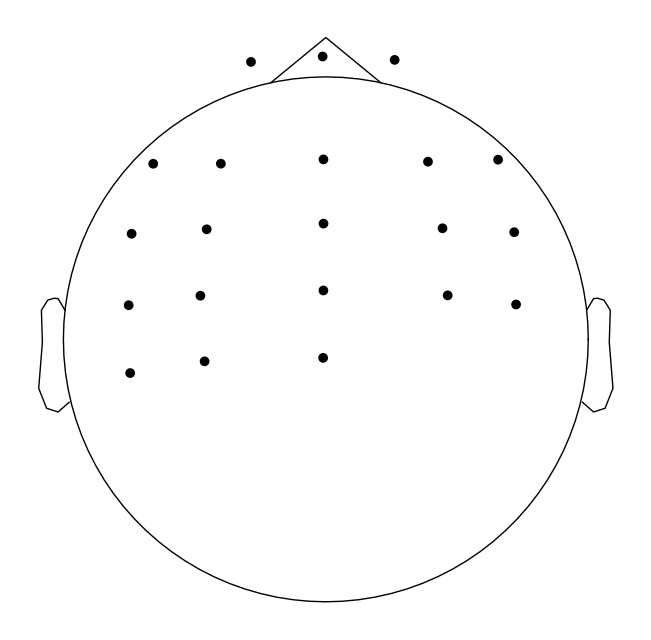

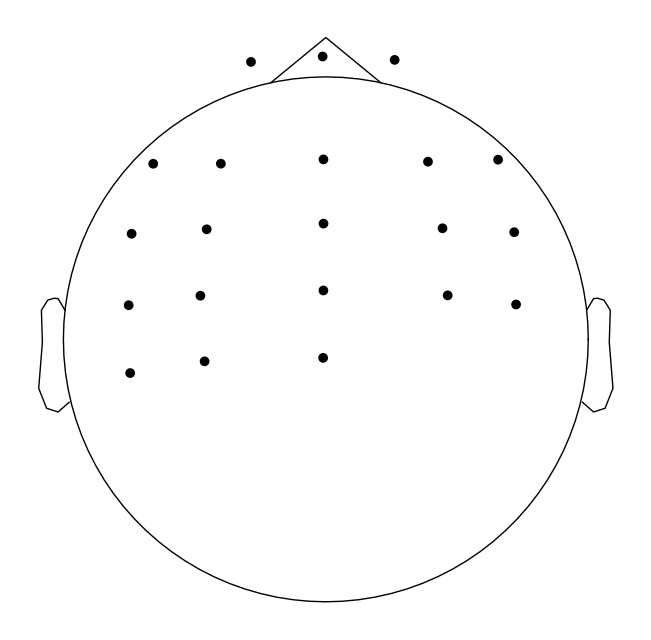

In [8]:
### определяем схему монтажа, входные параметры: тип монтажа, размер головы (радиус в метрах, по умолчанию 95 мм)
montage = mne.channels.make_standard_montage('standard_1020') # расположение электродов в соответствии с международной системой 10-20
### установить монтаж
renamer(rec1)
rec1.set_montage(montage);  # вместо raw указывается название конкретной записи (rec1, rec2 или rec3)
### визуализация схемы монтажа
rec1.plot_sensors()

In [7]:
def renamer(raw):
    a = raw.ch_names
    b = ['Fp1','Fpz','Fp2', 'F7', 'F3','Fz','F4','F8','FT7', 'FC3', 'FCz','FC4','FT8','T3','C3','Cz','C4', 'T4', 'TP7', 'CP3', 'CPz','CP4','TP8','A1','P5','T5','P3','Pz','P4','T6','A2','PO3','POz','PO4','P6','PO7','O1','Oz','O2','PO8']
    newch ={}
    for i in range(21):
        ch = {a[i]:b[i]}
        newch.update(ch)
    raw.rename_channels(newch)
    return raw

In [9]:
### удалить канал (если нужно!)
rec1.drop_channels('CPz')

<RawEDF | Subject13_2.edf, 20 x 31000 (62.0 s), ~4.8 MB, data loaded>

Using matplotlib as 2D backend.


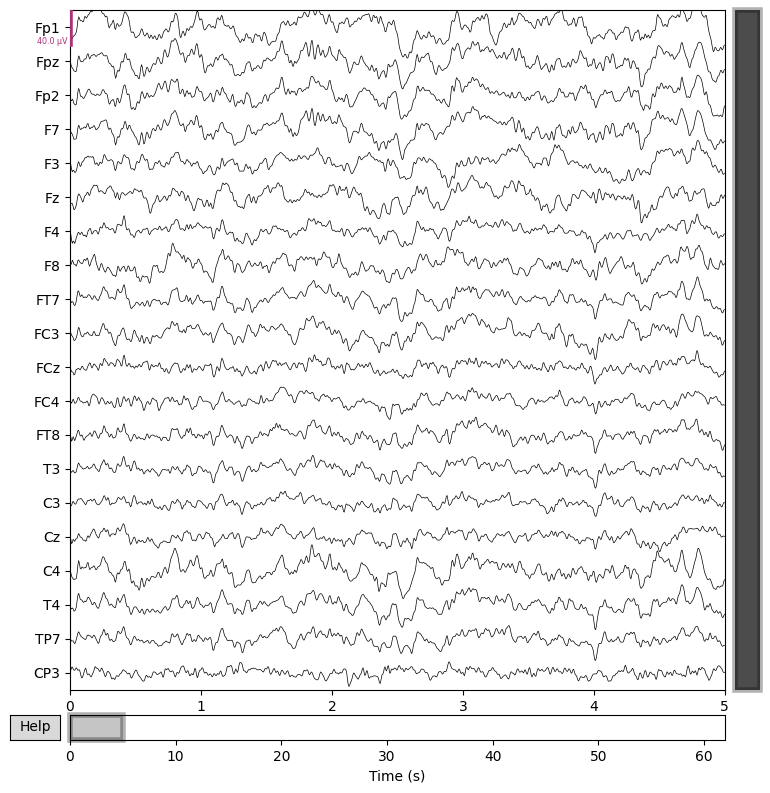

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 4.096 (s)
Plotting power spectral density (dB=True).


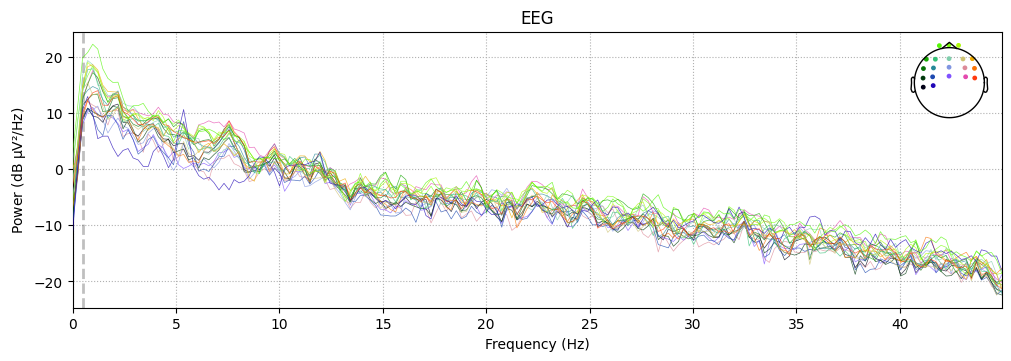

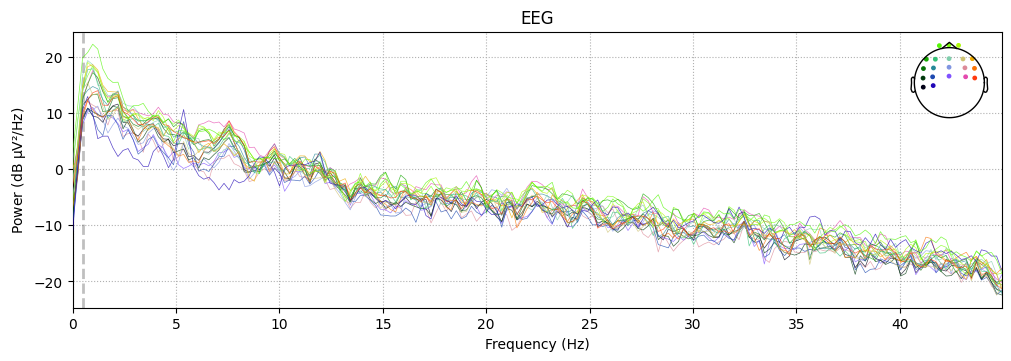

In [10]:
rec1.plot(duration=5, n_channels=20) # визуализация необработанных данных
rec1.plot_psd(fmax=45) # спектральная плотность мощности (ограничиваемся частотами до 50 Гц)

In [11]:
# расчет среднего референца по всем каналам
mne.set_eeg_reference(rec1);

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 11.25 Hz (-6 dB cutoff frequency: 50.62 Hz)
- Filter length: 1651 samples (3.302 s)

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 4.096 (s)
Plotting power spectral density (dB=True).


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s


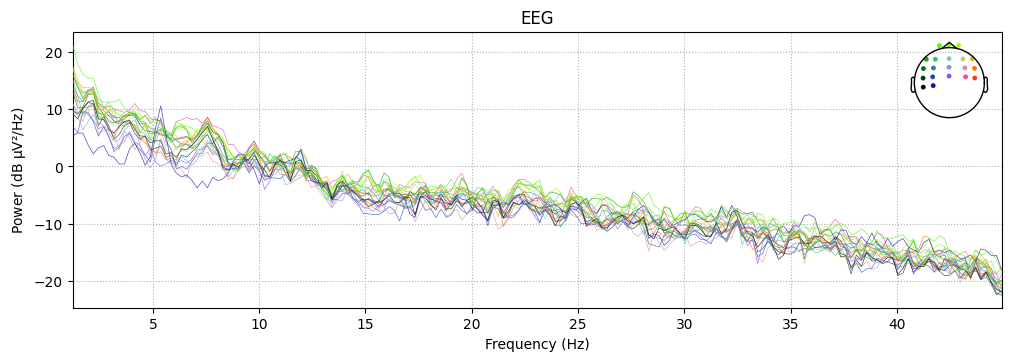

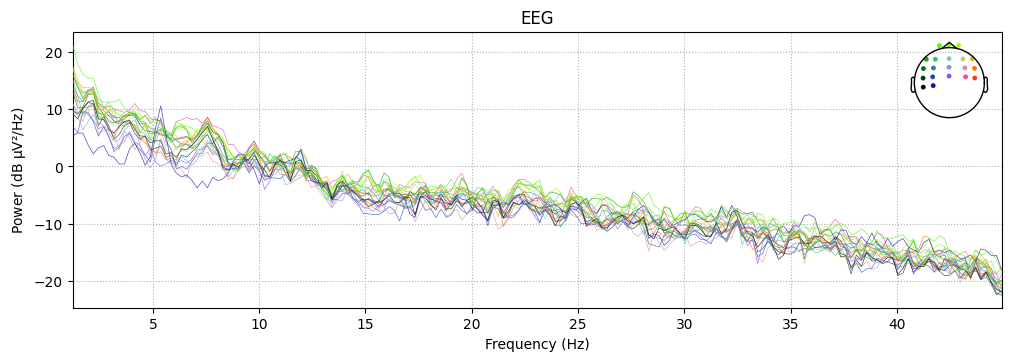

In [12]:
### частотная фильтрация (выделение диапазона исследования)
rec1.filter(1, 45, fir_design='firwin', skip_by_annotation='edge')
rec1.plot_psd(fmin=1, fmax=45)

In [13]:
events = mne.make_fixed_length_events(rec1, duration=2.0)

In [14]:
epochs = mne.Epochs(rec1, events, tmin=-0.2, tmax=0.5, preload=True)

Not setting metadata
31 matching events found
Setting baseline interval to [-0.2, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 31 events and 351 original time points ...
1 bad epochs dropped


In [15]:
DATA=rec1.get_data()

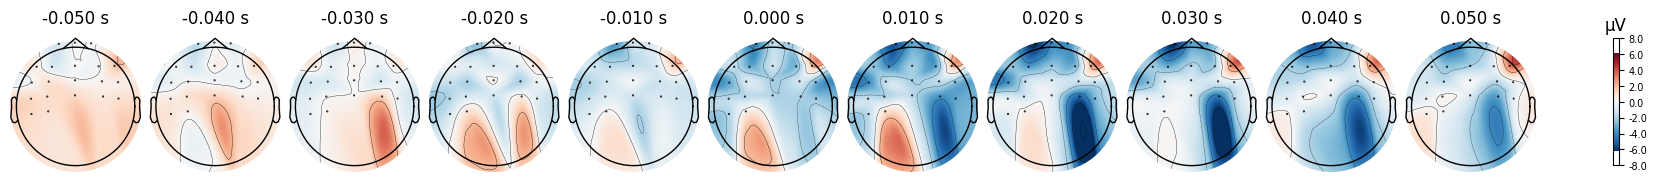

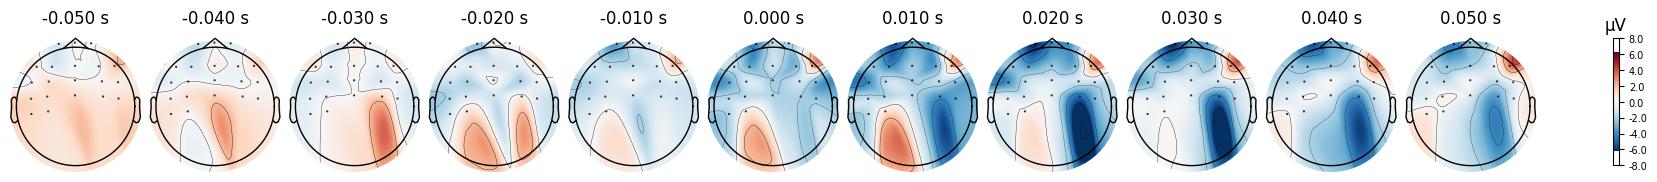

In [16]:
evoked = epochs.average()
evoked.plot_topomap(times=np.linspace(-0.05, 0.05, 11))

In [17]:
eog_epochs = mne.preprocessing.create_eog_epochs(rec1, ch_name='Fp1') # генерируем эпохи, связанные с ЭОГ

Using EOG channel: Fp1
EOG channel index for this subject is: [0]
Filtering the data to remove DC offset to help distinguish blinks from saccades
Selecting channel Fp1 for blink detection
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5000 samples (10.000 s)

Now detecting blinks and generating corresponding events
Found 73 significant peaks
Number of EOG events detected: 73
Not setting metadata
73 matching events found
No baseline correction applied
Using data from preloaded Raw for 73 events and 501 original time points ...
1 bad epochs dropped


Not setting metadata
72 matching events found
No baseline correction applied
0 projection items activated
combining channels using "mean"


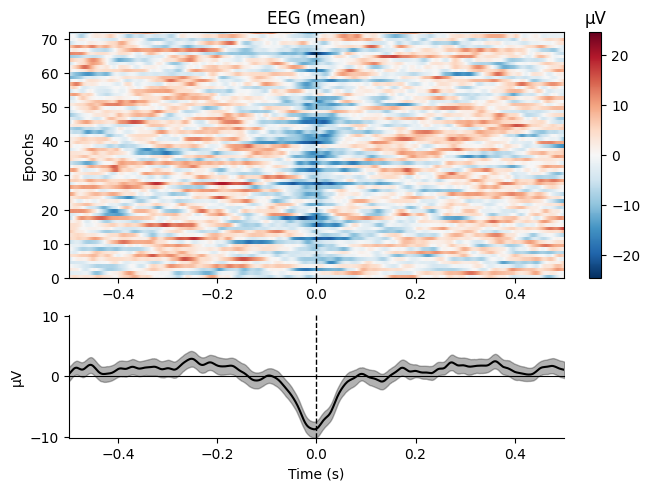

No projector specified for this dataset. Please consider the method self.add_proj.


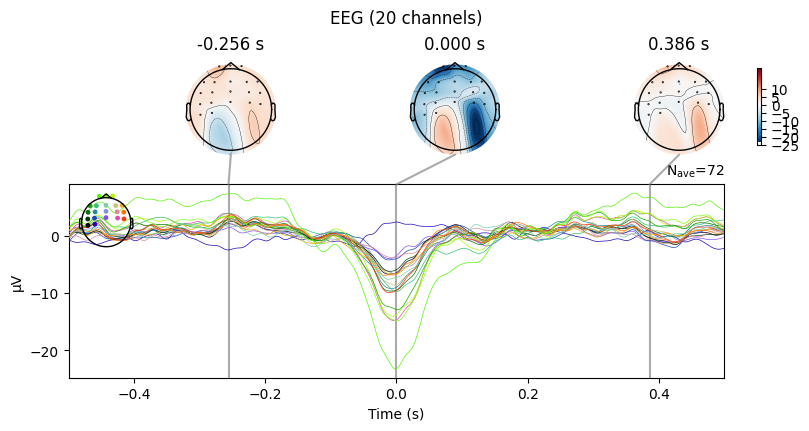

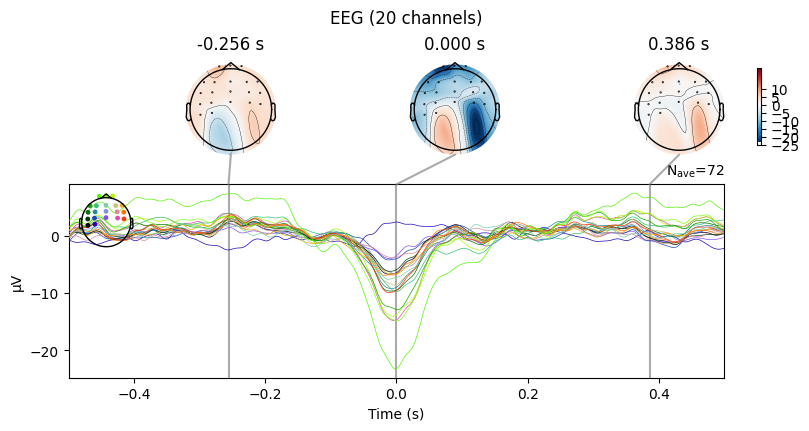

In [18]:
# карта изображения эпох с графиком среднего ERP по артефактам
eog_epochs.plot_image(combine='mean')

# нижний график отображает усредненные артефакты по каждому каналу
# топографическая карта показывает, в какой части головы наиболее выражена их амплитуда
eog_epochs.average().plot_joint()

In [19]:
filt_raw = rec1.copy()
filt_raw.load_data().filter(l_freq=1., h_freq=None)

Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 1651 samples (3.302 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s


<RawEDF | Subject13_2.edf, 20 x 31000 (62.0 s), ~4.8 MB, data loaded>

In [20]:
ica = mne.preprocessing.ICA(n_components=20, random_state=97)
ica.fit(filt_raw) # обучение алгоритма на имеющихся данных

Fitting ICA to data using 20 channels (please be patient, this may take a while)
Selecting by number: 20 components
Fitting ICA took 4.9s.


Method,fastica
Fit parameters,algorithm=parallelfun=logcoshfun_args=Nonemax_iter=1000
Fit,76 iterations on raw data (31000 samples)
ICA components,20
Available PCA components,20
Channel types,eeg
ICA components marked for exclusion,—


Creating RawArray with float64 data, n_channels=20, n_times=31000
    Range : 0 ... 30999 =      0.000 ...    61.998 secs
Ready.


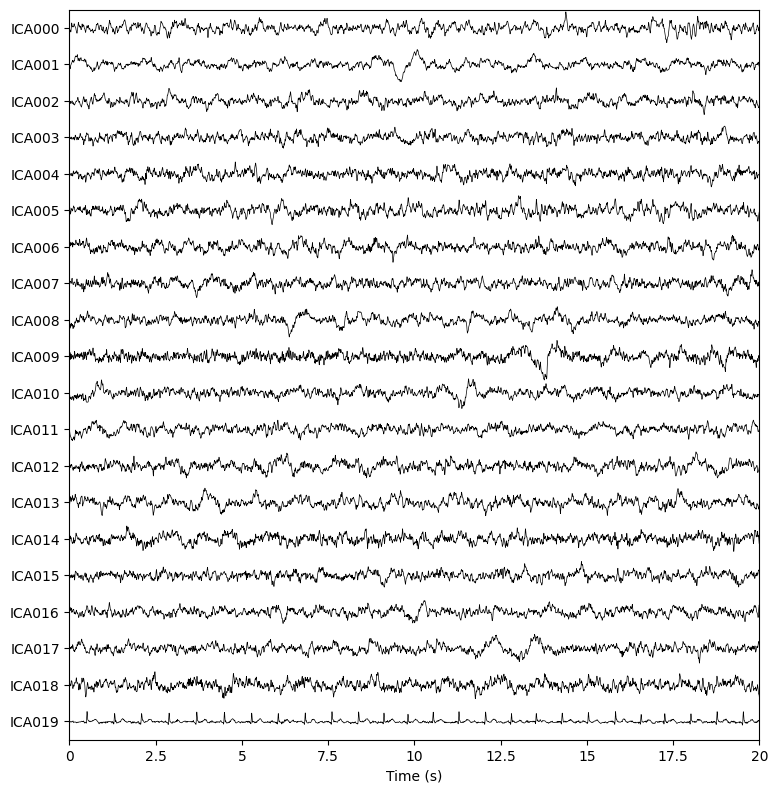

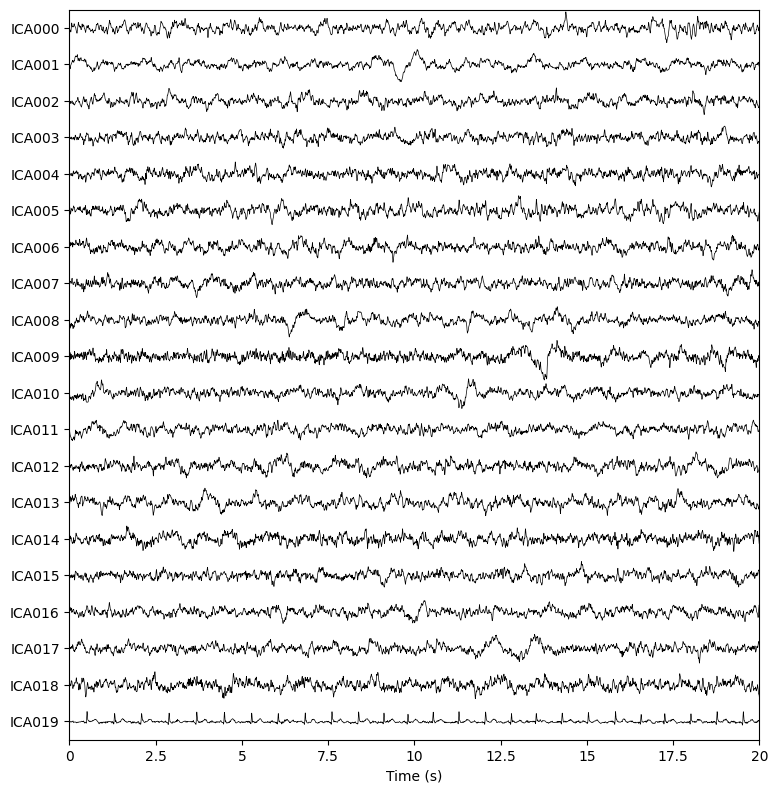

In [21]:
rec1.load_data()
ica.plot_sources(rec1, show_scrollbars=False)

In [22]:
ica.plot_components()

Output hidden; open in https://colab.research.google.com to view.

Applying ICA to Raw instance
    Transforming to ICA space (20 components)
    Zeroing out 1 ICA component
    Projecting back using 20 PCA components


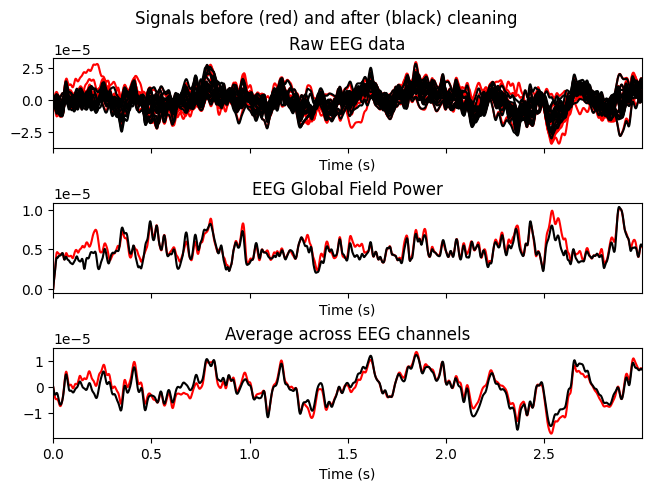

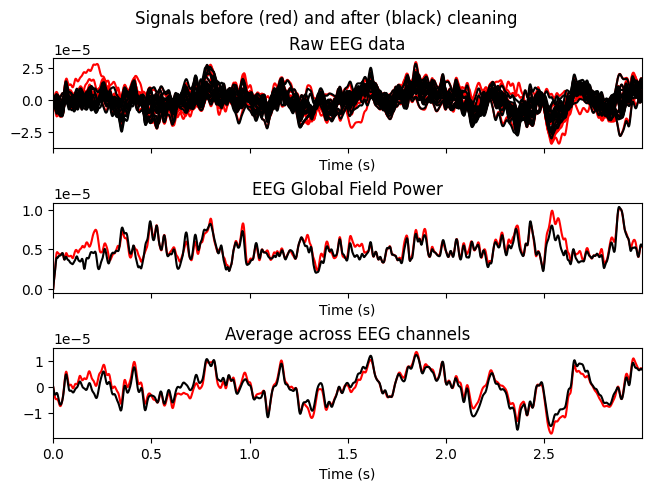

In [23]:
ica.plot_overlay(rec1, exclude=[1])

In [24]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

import mne
from mne.baseline import rescale
from mne.stats import bootstrap_confidence_interval

In [30]:
# let's explore some frequency bands
iter_freqs = [
    ('Theta', 4, 7),
    ('Alpha', 8, 12),
    ('Beta', 13, 25),
    ('Gamma', 30, 45)
]
# set epoching parameters
baseline = None

# get the header to extract events
raw_copy = rec1.copy()
events = mne.make_fixed_length_events(raw_copy, duration=2.0)

frequency_map = list()

for band, fmin, fmax in iter_freqs:
    raw_copy = rec1.copy()

    # bandpass filter
    raw_copy.filter(fmin, fmax, n_jobs=1,  # use more jobs to speed up.
               l_trans_bandwidth=1,  # make sure filter params are the same
               h_trans_bandwidth=1)  # in each band and skip "auto" option.

    # epoch
    epochs = mne.Epochs(raw_copy, events, event_id=1, tmin=-0.2, tmax=0.5, baseline=baseline,
                        preload=True,)
    # remove evoked response
    epochs.subtract_evoked()

    # get analytic signal (envelope)
    epochs.apply_hilbert(envelope=True)
    frequency_map.append(((band, fmin, fmax), epochs.average()))
    del epochs
del raw_copy

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 4 - 7 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 4.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 3.50 Hz)
- Upper passband edge: 7.00 Hz
- Upper transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 7.50 Hz)
- Filter length: 1651 samples (3.302 s)

Not setting metadata
31 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 31 events and 351 original time points ...
1 bad epochs dropped
Subtracting Evoked from Epochs
[done]
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 12 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windo

Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)


Text(0.5, 0, 'Time [ms]')

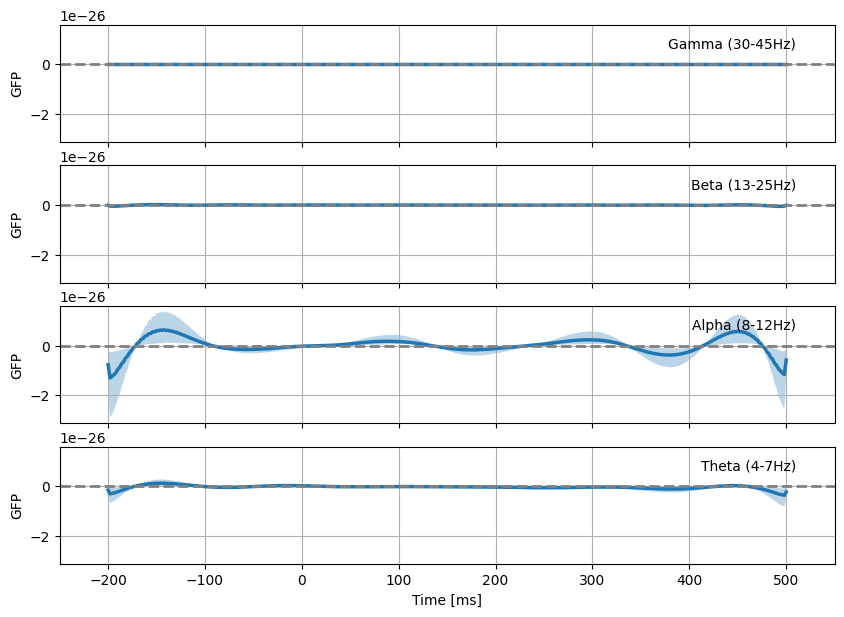

In [31]:
# Helper function for plotting spread
def stat_fun(x):
    """Return sum of squares."""
    return np.sum(x ** 2, axis=0)


# Plot
fig, axes = plt.subplots(4, 1, figsize=(10, 7), sharex=True, sharey=True)
#colors = plt.colormaps['winter_r'](np.linspace(0, 1, 4))
for ((freq_name, fmin, fmax), average),  ax in zip(
        frequency_map,  axes.ravel()[::-1]):
    times = average.times * 1e3
    gfp = np.sum(average.data ** 2, axis=0)
    gfp = mne.baseline.rescale(gfp, times, baseline=(None, 0))
    ax.plot(times, gfp, label=freq_name,  linewidth=2.5)
    ax.axhline(0, linestyle='--', color='grey', linewidth=2)
    ci_low, ci_up = bootstrap_confidence_interval(average.data, random_state=0,
                                                  stat_fun=stat_fun)
    ci_low = rescale(ci_low, average.times, baseline=(None, 0))
    ci_up = rescale(ci_up, average.times, baseline=(None, 0))
    ax.fill_between(times, gfp + ci_up, gfp - ci_low,  alpha=0.3)
    ax.grid(True)
    ax.set_ylabel('GFP')
    ax.annotate('%s (%d-%dHz)' % (freq_name, fmin, fmax),
                xy=(0.95, 0.8),
                horizontalalignment='right',
                xycoords='axes fraction')
    ax.set_xlim(-250, 550)

axes.ravel()[-1].set_xlabel('Time [ms]')